In [2]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
from nltk.tokenize import sent_tokenize


In [3]:
headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
res = requests.get('https://en.wikipedia.org/wiki/Machine_learning', headers=headers)
res

<Response [200]>

In [4]:
soup = BeautifulSoup(res.text, 'html.parser')
soup

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>Machine learning - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature

In [5]:
headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
res = requests.get('https://en.wikipedia.org/wiki/Machine_learning', headers=headers)
Ml = BeautifulSoup(res.text, 'html.parser')
text=Ml.getText(strip=True)
sentences = sent_tokenize(text)        
data = pd.DataFrame(sentences, columns=['Text'])  
data

,Text
0,Machine learning - WikipediaJump to contentMai...
1,"""Statistical learning"" redirects here."
2,"For statistical learning in linguistics, seeSt..."
3,"[1]Within a subdiscipline of machine learning,..."
4,"[3][4]From a theoretical viewpoint,probably ap..."
...,...
684,(2015)Introduction to Machine LearningArchived...
685,"(4th edition) Pearson,ISBN978-0134610993.Solom..."
686,(2011).Data Mining: Practical Machine Learning...
687,"By using this site, you agree to theTerms of U..."


In [6]:
data.to_csv('SentenceRaw.csv')

In [7]:
import re
from nltk.corpus import stopwords
def Clean(text):
     clean_words=[]
     text = str(text).lower()
     text = re.sub(r'\[\d+\]', '', text)  
     text = re.sub(r'\[\w+\]', '', text)
     text = re.sub(r'_', '', text)
     text = re.sub(r'\s+', ' ', text).strip()  
     for word in text.split():
        if word not in set(stopwords.words('english')):  # Bug 4 fixed
            clean_words.append(word)

     return text

clean_text=[]
for Text in data['Text'].values:
    clean_text.append(Clean(Text))


clean_text


Clean_data=pd.DataFrame(clean_text,columns=['Text'])
Clean_data.to_csv('Clean_Text.csv')
Clean_data

,Text
0,machine learning - wikipediajump to contentmai...
1,"""statistical learning"" redirects here."
2,"for statistical learning in linguistics, seest..."
3,"within a subdiscipline of machine learning, ad..."
4,"from a theoretical viewpoint,probably approxim..."
...,...
684,(2015)introduction to machine learningarchived...
685,"(4th edition) pearson,isbn978-0134610993.solom..."
686,(2011).data mining: practical machine learning...
687,"by using this site, you agree to theterms of u..."


In [8]:
Clean_data.Text.values[200:]

array(['some successful applications of deep learning are computer vision and speech recognition.',
       "decision treesmain article:decision tree learninga decision tree showing survival probability of passengers on thetitanicdecision tree learning uses adecision treeas apredictive modelto go from observations about an item (represented in the branches) to conclusions about the item's target value (represented in the leaves).",
       'it is one of the predictive modelling approaches used in statistics, data mining, and machine learning.',
       'tree models where the target variable can take a discrete set of values are called classification trees; in these tree structures,leavesrepresent class labels, and branches representconjunctionsof features that lead to those class labels.',
       'decision trees where the target variable can take continuous values (typicallyreal numbers) are called regression trees.',
       'in decision analysis, a decision tree can be used to visually a

In [9]:
!pip install textblob
from textblob import TextBlob
from textblob import TextBlob   

def analyze_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity>0:
        return 'positive'
    elif analysis.sentiment.polarity==0:
            return 'Neutral'
    else:
        return 'NEgative'


In [10]:
Clean_data['Label']=[analyze_sentiment(x) for x in Clean_data.Text]
Clean_data

,Text,Label
0,machine learning - wikipediajump to contentmai...,positive
1,"""statistical learning"" redirects here.",Neutral
2,"for statistical learning in linguistics, seest...",NEgative
3,"within a subdiscipline of machine learning, ad...",positive
4,"from a theoretical viewpoint,probably approxim...",NEgative
...,...,...
684,(2015)introduction to machine learningarchived...,positive
685,"(4th edition) pearson,isbn978-0134610993.solom...",Neutral
686,(2011).data mining: practical machine learning...,NEgative
687,"by using this site, you agree to theterms of u...",Neutral


In [ ]:
from nltk.tokenize import word_tokenize

MlWords = word_tokenize(Ml.text)
MlWords

['Machine',
 'learning',
 '-',
 'Wikipedia',
 'Jump',
 'to',
 'content',
 'Main',
 'menu',
 'Main',
 'menu',
 'move',
 'to',
 'sidebar',
 'hide',
 'Navigation',
 'Main',
 'pageContentsCurrent',
 'eventsRandom',
 'articleAbout',
 'WikipediaContact',
 'us',
 'Contribute',
 'HelpLearn',
 'to',
 'editCommunity',
 'portalRecent',
 'changesUpload',
 'fileSpecial',
 'pages',
 'Search',
 'Search',
 'Appearance',
 'Donate',
 'Create',
 'account',
 'Log',
 'in',
 'Personal',
 'tools',
 'Donate',
 'Create',
 'account',
 'Log',
 'in',
 'Contents',
 'move',
 'to',
 'sidebar',
 'hide',
 '(',
 'Top',
 ')',
 '1',
 'History',
 '2',
 'Relationships',
 'to',
 'other',
 'fields',
 'Toggle',
 'Relationships',
 'to',
 'other',
 'fields',
 'subsection',
 '2.1',
 'Artificial',
 'intelligence',
 '2.2',
 'Data',
 'compression',
 '2.3',
 'Data',
 'mining',
 '2.4',
 'Generalization',
 '2.5',
 'Statistics',
 '2.6',
 'Statistical',
 'physics',
 '3',
 'Theory',
 '4',
 'Approaches',
 'Toggle',
 'Approaches',
 'subsec

In [ ]:
MlWords = [word for word in MlWords if word.isalnum()]
MlWords

MlWords =[word for word in MlWords if not str.lower(word) in set(stopwords.words('english'))]

In [ ]:
from collections import Counter

word_counts = Counter(MlWords)

print(word_counts)


Counter({'learning': 306, 'machine': 136, 'data': 116, 'Machine': 103, 'Learning': 95, 'Archived': 77, 'Retrieved': 77, 'AI': 75, 'original': 71, 'edit': 62, 'model': 61, 'algorithms': 57, 'training': 49, '2018': 48, 'ISBN': 47, 'models': 46, 'Artificial': 42, 'neural': 40, 'artificial': 39, 'used': 36, 'set': 36, '2020': 33, 'networks': 32, 'network': 32, 'August': 32, 'systems': 31, 'intelligence': 30, 'also': 30, 'algorithm': 30, 'methods': 29, '2019': 29, 'June': 29, 'theory': 28, 'Intelligence': 28, '2021': 27, 'PDF': 27, 'Data': 26, 'analysis': 26, 'Main': 25, '17': 25, '2022': 25, 'classification': 24, '2023': 24, 'S2CID': 24, 'computing': 23, 'example': 23, 'January': 23, 'regression': 22, 'field': 22, 'article': 22, '1': 21, 'detection': 21, 'Computational': 21, '2016': 21, '2017': 21, 'March': 21, 'language': 20, 'input': 20, 'November': 20, 'Neural': 19, 'using': 19, 'system': 19, 'Science': 19, 'PMID': 19, 'compression': 18, 'mining': 18, '9': 18, '11': 18, 'Software': 18, 

(-0.5, 999.5, 499.5, -0.5)

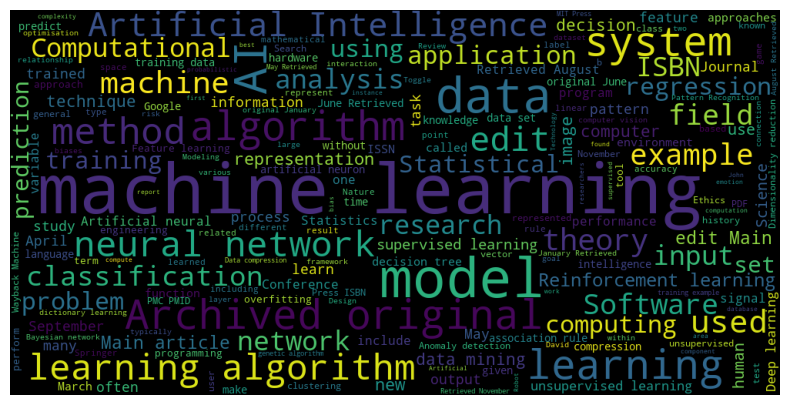

In [ ]:
!pip install WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

MlWords = (" ").join(MlWords)     # word1 word2 word3  as word cloud take a text as a string not list

wordcloud = WordCloud(width=1000,height=500).generate(MlWords)   
plt.figure(figsize=(15,5))
plt.imshow(wordcloud)
plt.axis('off')